# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|        Bima Satriawan      |   5054251031    |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('WineQT.csv')
data.head()
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [3]:
data.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [4]:
data.duplicated().sum()

np.int64(0)

In [5]:
corr_matrix = data.corr()
corr_matrix['quality'].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
Id                      0.069708
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64

<Axes: xlabel='quality', ylabel='alcohol'>

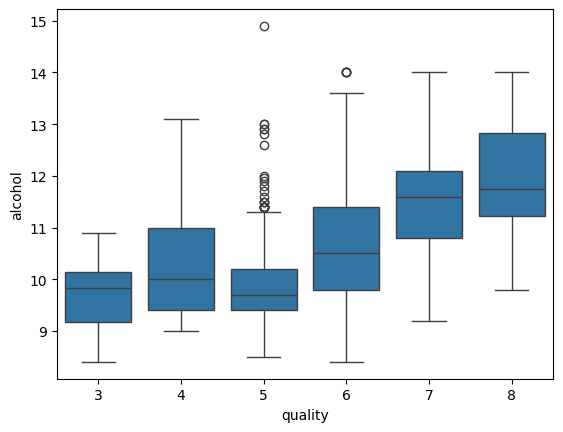

In [6]:
sns.boxplot(x='quality', y='alcohol', data=data)

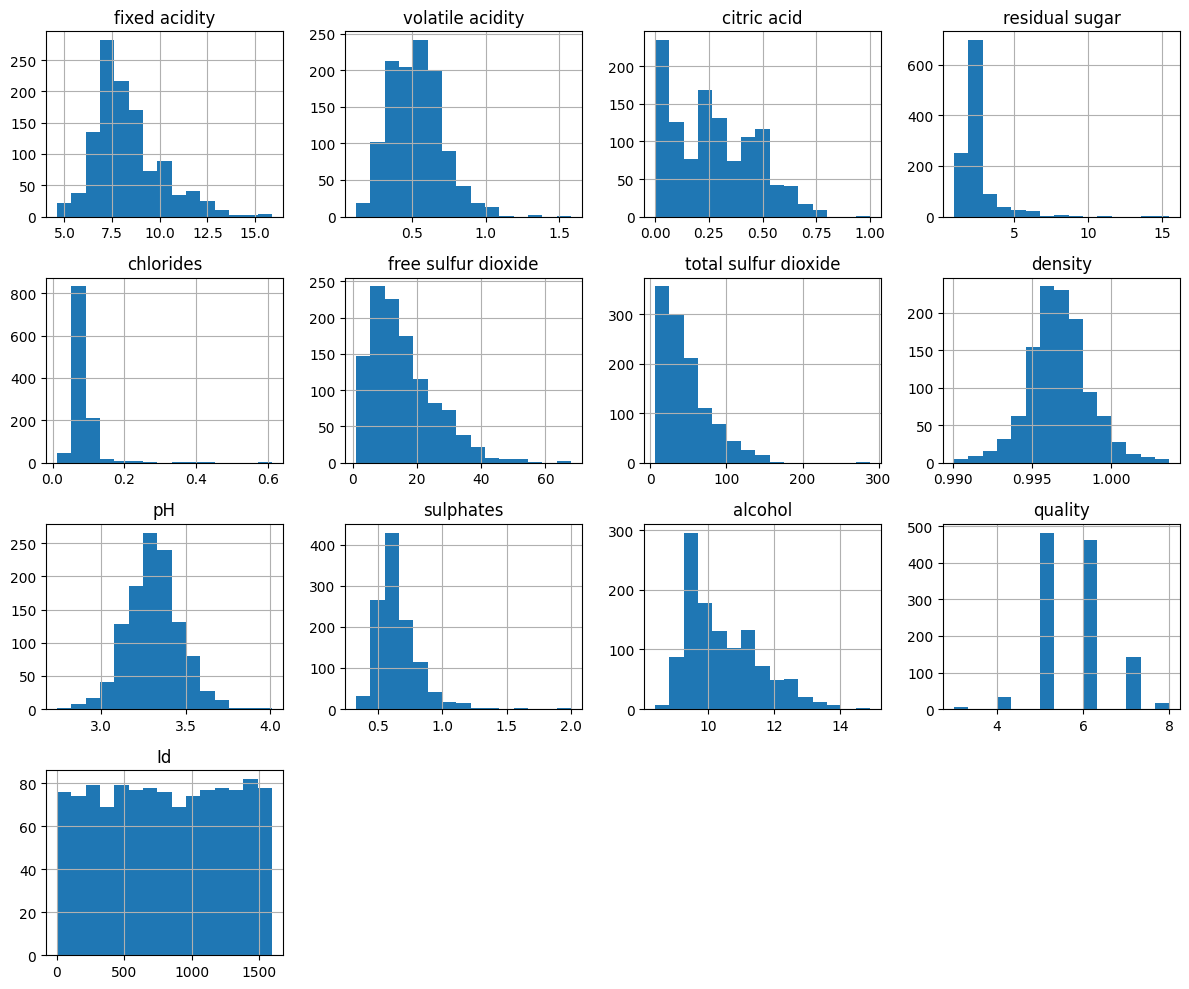

In [7]:
data.hist(figsize=(12, 10), bins=15)
plt.tight_layout()
plt.show()

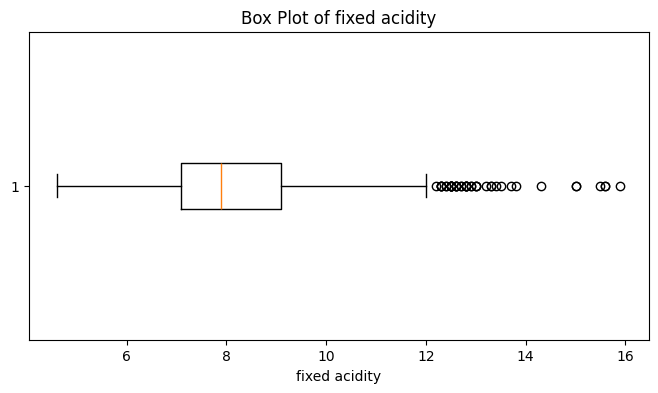

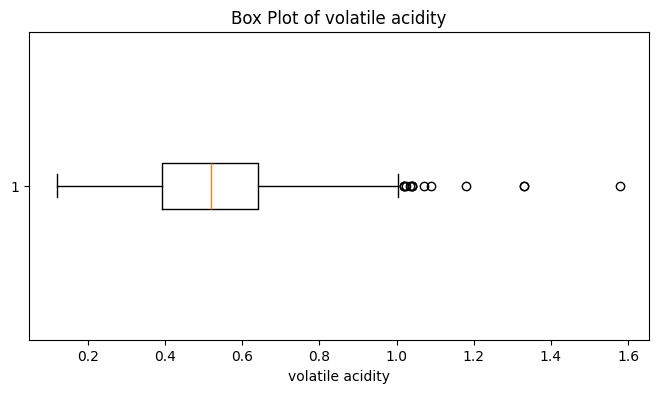

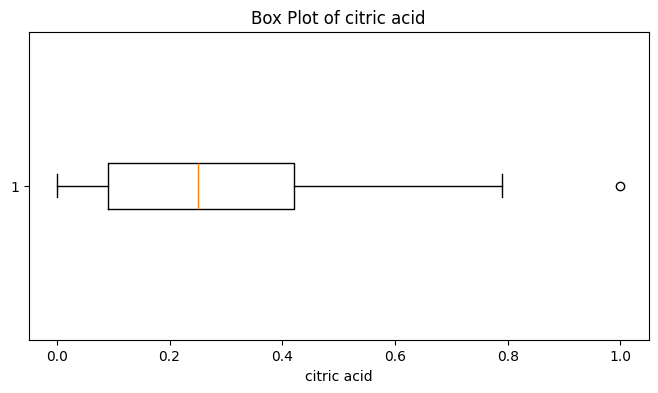

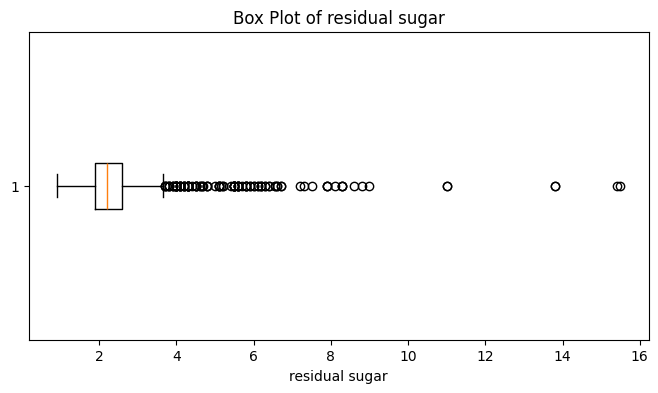

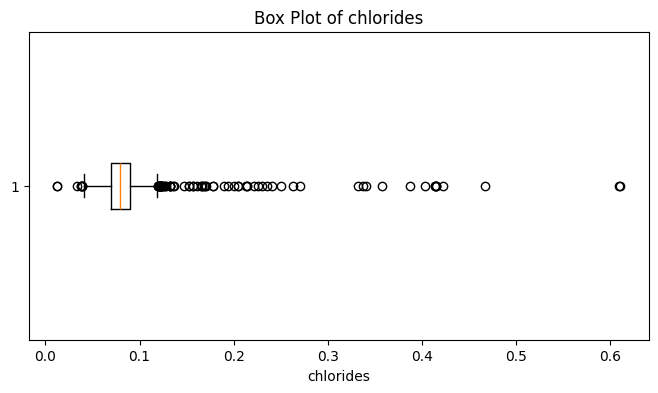

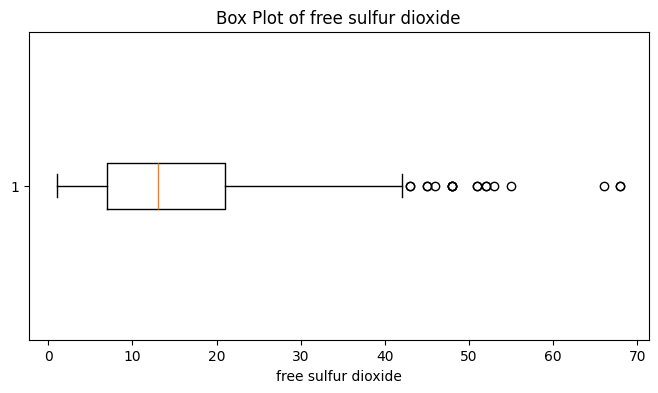

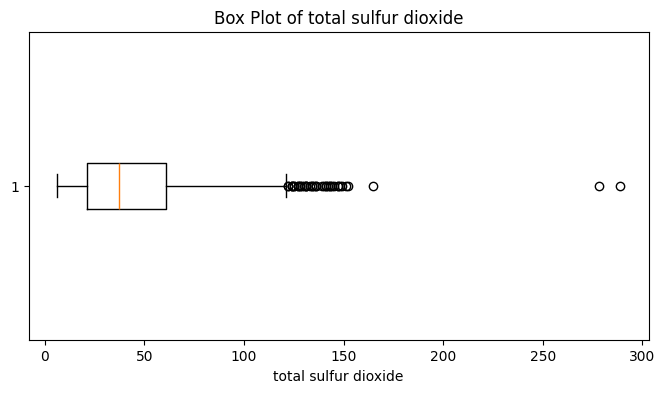

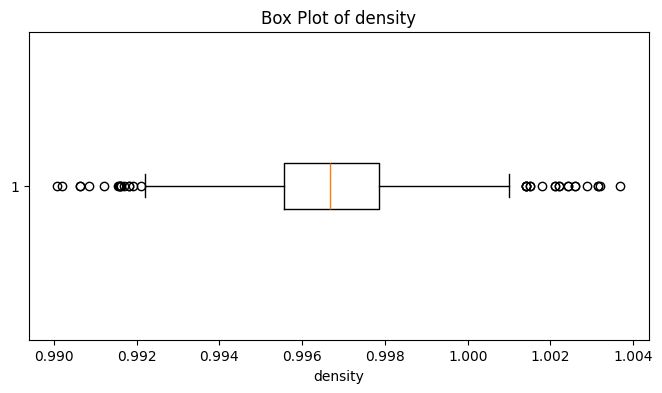

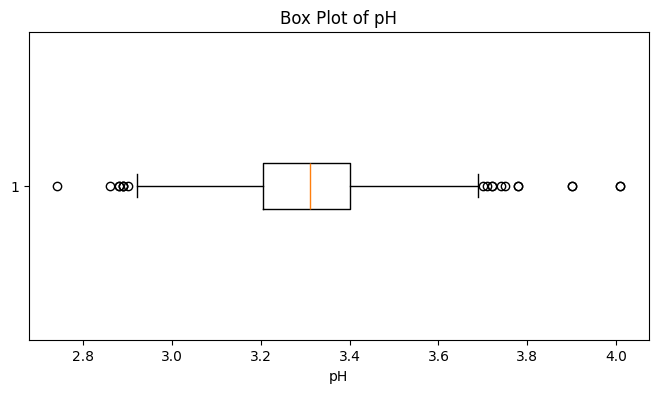

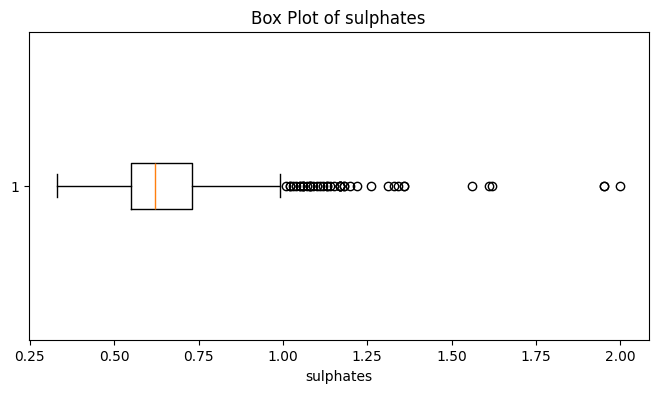

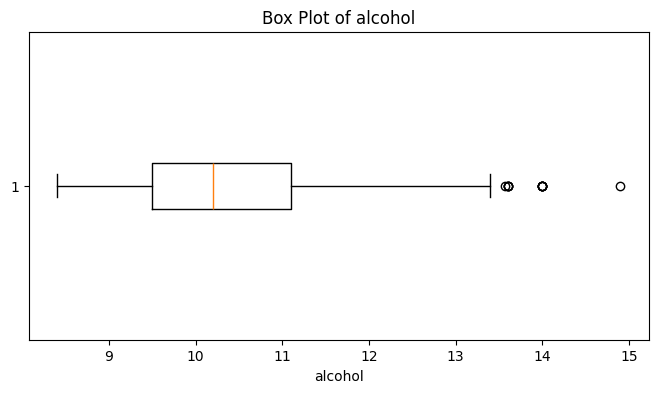

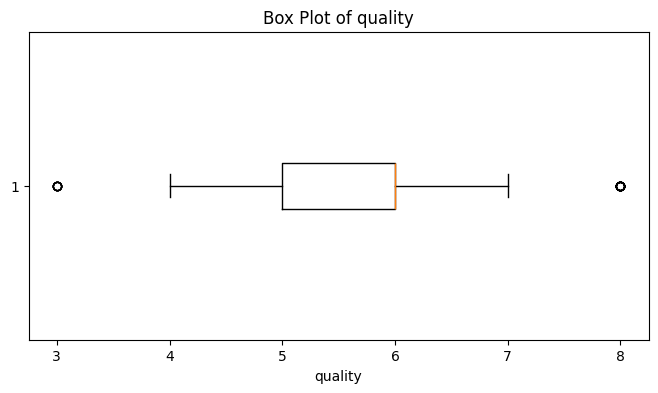

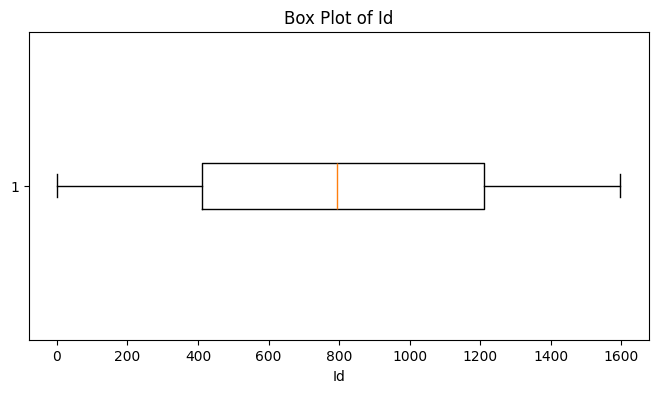

In [8]:
for i, col in enumerate(data.columns):
    plt.figure(figsize=(8, 4))
    plt.boxplot(data[col], vert=False)
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.show()

# 2. Preprocessing




### Tidak ada data duplikat dan data missing values.

In [9]:
data.drop('Id', axis=1) #tidak butuhkan karena tidak berpengaruh pada kualitas wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6


In [10]:
# Persiapan data dengan dan tanpa outlier untuk membandingkan performa model KNN.
data_original = data.copy()
data_clean = data.copy()
features = [col for col in data.columns if col != 'quality']

Q1 = data_clean[features].quantile(0.25)
Q3 = data_clean[features].quantile(0.75)
IQR = Q3 - Q1

non_outlier_mask = ~((data_clean[features] < (Q1 - 1.5 * IQR)) & (data_clean[features] > (Q3 + 1.5 * IQR))).any(axis=1)

data_clean = data_clean[non_outlier_mask].reset_index(drop=True)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Data DENGAN outlier
x_original = data_original.drop('quality', axis=1)
y_original = data_original['quality']

x_train_original, x_test_original, y_train_original, y_test_original = train_test_split(x_original, y_original, test_size=0.2, random_state=42, stratify=y_original)

x_train_original = scaler.fit_transform(x_train_original)
x_test_original = scaler.transform(x_test_original)

# Data TANPA outlier
x_clean = data_clean.drop('quality', axis=1)
y_clean = data_clean['quality']

x_train_clean, x_test_clean, y_train_clean, y_test_clean = train_test_split(x_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean)

x_train_clean = scaler.fit_transform(x_train_clean)
x_test_clean = scaler.transform(x_test_clean)

# 3. Eksperimen Model KNN


In [12]:
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

k_values = [15,17,19,23,27,31,33,37]
metrics = ['euclidean', 'manhattan']

def evaluasi_knn(k, metric, x_train, y_train, x_test, y_test):
    results = []
    for k in k_values:
        for metric in metrics:
            model = KNeighborsClassifier(n_neighbors=k, metric=metric)
            model.fit(x_train, y_train)
            y_pred = model.predict(x_test)
            
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
            rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
            f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
            results.append({
                'k': k,
                'metric': metric,
                'accuracy': acc,
                'precision': prec,
                'recall': rec,
                'f1_score': f1
            })
    return pd.DataFrame(results)

data_results_original = evaluasi_knn(k_values, metrics, x_train_original, y_train_original, x_test_original, y_test_original)
data_results_clean = evaluasi_knn(k_values, metrics, x_train_clean, y_train_clean, x_test_clean, y_test_clean)

print("Evaluasi KNN untuk data DENGAN outlier:")
print(data_results_original)

print("Evaluasi KNN untuk data TANPA outlier:")
print(data_results_clean)

Evaluasi KNN untuk data DENGAN outlier:
     k     metric  accuracy  precision    recall  f1_score
0   15  euclidean  0.620087   0.587101  0.620087  0.600732
1   15  manhattan  0.606987   0.574289  0.606987  0.586758
2   17  euclidean  0.641921   0.607361  0.641921  0.620456
3   17  manhattan  0.633188   0.599964  0.633188  0.607604
4   19  euclidean  0.624454   0.585032  0.624454  0.601241
5   19  manhattan  0.637555   0.601293  0.637555  0.609580
6   23  euclidean  0.668122   0.628297  0.668122  0.638930
7   23  manhattan  0.637555   0.610744  0.637555  0.609369
8   27  euclidean  0.646288   0.609345  0.646288  0.618684
9   27  manhattan  0.637555   0.605797  0.637555  0.610973
10  31  euclidean  0.628821   0.595679  0.628821  0.603065
11  31  manhattan  0.633188   0.609489  0.633188  0.604148
12  33  euclidean  0.624454   0.591823  0.624454  0.598037
13  33  manhattan  0.628821   0.613816  0.628821  0.600182
14  37  euclidean  0.611354   0.585429  0.611354  0.587473
15  37  manhatta

In [13]:
best_original = data_results_original.sort_values(by='f1_score', ascending=False).head(1)
best_clean = data_results_clean.sort_values(by='f1_score', ascending=False).head(1)

print("Hasil terbaik untuk data DENGAN outlier:")
print(best_original)
print("Hasil terbaik untuk data TANPA outlier:")
print(best_clean)

Hasil terbaik untuk data DENGAN outlier:
    k     metric  accuracy  precision    recall  f1_score
6  23  euclidean  0.668122   0.628297  0.668122   0.63893
Hasil terbaik untuk data TANPA outlier:
    k     metric  accuracy  precision    recall  f1_score
6  23  euclidean  0.668122   0.628297  0.668122   0.63893


# 4. Evaluasi Model


In [14]:
knn_original = KNeighborsClassifier(n_neighbors=best_original['k'].values[0], metric=best_original['metric'].values[0])
knn_original.fit(x_train_original, y_train_original)
y_pred_original = knn_original.predict(x_test_original)

knn_clean = KNeighborsClassifier(n_neighbors=best_clean['k'].values[0], metric=best_clean['metric'].values[0])
knn_clean.fit(x_train_clean, y_train_clean)
y_pred_clean = knn_clean.predict(x_test_clean)

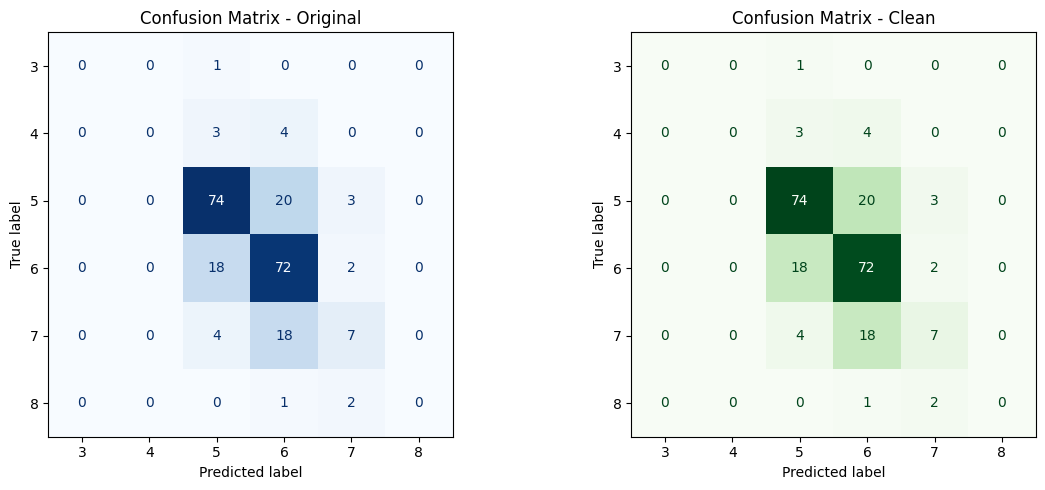

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_original, y_pred_original, 
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Confusion Matrix - Original')

ConfusionMatrixDisplay.from_predictions(
    y_test_clean, y_pred_clean, 
    ax=axes[1], cmap='Greens', colorbar=False
)
axes[1].set_title('Confusion Matrix - Clean')

plt.tight_layout()
plt.show()

# 5. Analisis

Berdasarkan hasil eksperimen yang telah dilakukan, berikut adalah analisis mendalam terkait performa model KNN pada dataset Wine Quality:
### 5.1 Perbandingan Data dengan dan tanpa Outlier

Hasil evaluasi menunjukkan bahwa tidak ada perbedaan signifikan antara performa model pada data original (dengan outlier) dan data clean (tanpa outlier).

Akurasi tertinggi pada kedua dataset adalah 0.668 dengan F1-score 0.639, menggunakan parameter k=23 dan metrik Euclidean.

Penghapusan outlier tidak memberikan peningkatan performa yang berarti. Hal ini dapat terjadi karena:

Jumlah outlier yang dihapus tidak signifikan.

Outlier mungkin masih mengandung pola yang berguna untuk klasifikasi.

Model KNN cukup robust terhadap noise jika nilai k cukup besar.

### 5.2 Pengaruh Nilai k

Semakin besar nilai k (hingga 23), akurasi cenderung meningkat, terutama pada metrik Euclidean.

Nilai k yang terlalu kecil (misal 11) menghasilkan performa yang lebih rendah, kemungkinan karena model terlalu sensitif terhadap data lokal atau noise.

k=23 memberikan performa terbaik, menunjukkan bahwa jumlah tetangga yang lebih banyak membantu generalisasi model.

### 5.3 Pengaruh Metrik Jarak

Euclidean secara konsisten memberikan hasil yang lebih baik dibandingkan Manhattan pada hampir semua nilai k.

Euclidean lebih cocok untuk data dengan skala fitur yang sudah distandarisasi (StandardScaler), karena mempertimbangkan jarak secara geometris.

Manhattan bekerja lebih baik pada dataset dengan dimensi tinggi, tetapi dalam kasus ini Euclidean lebih unggul.

### 5.4 Evaluasi Metrik Lain

Akurasi tertinggi: 0.668

Precision tertinggi: 0.628

Recall tertinggi: 0.668

F1-score tertinggi: 0.639

Metrik ini menunjukkan bahwa model cukup baik dalam mengklasifikasikan kelas mayoritas (kualitas 5 dan 6), namun masih kesulitan mendeteksi kelas minoritas (kualitas 3, 4, 7, 8) yang jumlah sampelnya lebih sedikit. Hal ini terlihat dari confusion matrix yang menunjukkan banyak prediksi salah pada kelas-kelas tersebut.

# 6. Kesimpulan dan Saran

### 6.1 Kesimpulan

Model KNN dengan k=23 dan metrik Euclidean memberikan performa terbaik dengan akurasi sekitar 66.8% dan F1-score 0.639.

Penghapusan outlier tidak meningkatkan performa model secara signifikan.

Performa model masih tergolong sedang, terutama karena ketidakseimbangan kelas pada dataset.

Fitur seperti alcohol, sulphates, dan citric acid memiliki korelasi positif tertinggi terhadap kualitas wine, sedangkan volatile acidity berkorelasi negatif.

### 6.2 Saran untuk Eksperimen Selanjutnya

Eksplorasi Nilai k Lainnya
Coba nilai k yang lebih besar (misal 25, 30, 35) untuk melihat apakah akurasi terus meningkat atau mulai menurun.